In [1]:
# This project analyzes historical U.S. air traffic passenger data to forecast airline performance for 2026 using machine learning techniques.
# Using monthly passenger statistics, the analysis estimates future demand, ranks airlines by growth,
# and evaluates projected market share among major carriers.

In [2]:
import pandas as pd
import numpy as np

# Load the raw air traffic passenger dataset from CSV
df = pd.read_csv(
    r'C:\Users\bobma\PycharmProjects\ML\Air_Traffic_Passenger_Statistics.csv'
)

# ✅ Convert date column BEFORE any grouping
df['Activity Period Start Date'] = pd.to_datetime(
    df['Activity Period Start Date'],
    errors='coerce'
)

# Create a unified airline column:
# use the operating airline when available,
# otherwise fall back to the published airline
df['Airline'] = df['Operating Airline'].fillna(df['Published Airline'])

# (optional but recommended) drop rows with missing airline or date
df = df.dropna(subset=['Airline', 'Activity Period Start Date'])

# Aggregate passenger counts by month and airline
# This produces total passengers transported by each airline per month
airline_monthly = (
    df.groupby(['Activity Period Start Date','Airline'])['Passenger Count']
      .sum()
      .reset_index()
      .sort_values('Activity Period Start Date')
)

# Preview the first rows of the monthly airline dataset
airline_monthly.head()

,Activity Period Start Date,Airline,Passenger Count
0,1999-07-01,ATA Airlines,65303
27,1999-07-01,Miami Air International,1286
28,1999-07-01,Midwest Airlines,6043
29,1999-07-01,National Airlines,12579
30,1999-07-01,Northwest Airlines (became Delta),184422


In [3]:
# Convert the date column to datetime format;
# invalid or unparsable values are replaced with NaT (missing datetime)
df['Activity Period Start Date'] = pd.to_datetime(
    df['Activity Period Start Date'],
    errors='coerce'
)

In [4]:
# Remove rows or columns where there are gaps
df['Airline'] = df['Operating Airline'].fillna(df['Published Airline'])
df = df.dropna(subset=['Airline'])

In [5]:
# Limit the period (2000–2025)

airline_monthly = airline_monthly[
    airline_monthly['Activity Period Start Date'].between(
        '2000-01-01', '2025-12-01'
    )
]

In [6]:
# Let's take the TOP airlines

top_airlines = (
    airline_monthly.groupby('Airline')['Passenger Count']
      .sum()
      .nlargest(10)
      .index
)

airline_monthly = airline_monthly[
    airline_monthly['Airline'].isin(top_airlines)
]

In [7]:
# Create forecast function for one airline

from sklearn.ensemble import RandomForestRegressor

def forecast_airline(data):

    ts = data.set_index('Activity Period Start Date') \
             .sort_index() \
             .asfreq('MS')

    ts = ts.rename(columns={'Passenger Count': 'Passengers'})

    # --- features ---
    ts['lag_1']  = ts['Passengers'].shift(1)
    ts['lag_12'] = ts['Passengers'].shift(12)
    ts['roll_3']  = ts['Passengers'].rolling(3).mean()
    ts['roll_12'] = ts['Passengers'].rolling(12).mean()
    ts['month'] = ts.index.month
    ts['year']  = ts.index.year

    ts = ts.dropna()

    train = ts.iloc[:-12]

    X = train.drop('Passengers', axis=1)
    y = train['Passengers']

    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X, y)

    # --- Forecast 2026 ---
    future_dates = pd.date_range('2026-01-01', periods=12, freq='MS')
    last_data = ts.copy()

    preds = []

    for date in future_dates:

        last_row = last_data.iloc[-1]

        new_row = {
            'lag_1':  last_row['Passengers'],
            'lag_12': last_data.iloc[-12]['Passengers'],
            'roll_3':  last_data['Passengers'].iloc[-3:].mean(),
            'roll_12': last_data['Passengers'].iloc[-12:].mean(),
            'month': date.month,
            'year':  date.year
        }

        X_new = pd.DataFrame([new_row])
        pred = model.predict(X_new)[0]

        preds.append(pred)

        last_data.loc[date] = [pred] + list(new_row.values())

    return sum(preds)

In [8]:
def forecast_airline(data):
    ts = (data.set_index('Activity Period Start Date')
              .sort_index()
              .asfreq('MS'))

    ts = ts.rename(columns={'Passenger Count': 'Passengers'})

    # --- features ---
    ts['lag_1']  = ts['Passengers'].shift(1)
    ts['lag_12'] = ts['Passengers'].shift(12)
    ts['roll_3']  = ts['Passengers'].rolling(3).mean()
    ts['roll_12'] = ts['Passengers'].rolling(12).mean()
    ts['month'] = ts.index.month
    ts['year']  = ts.index.year

    ts = ts.dropna()

    # Not enough data after feature engineering
    if len(ts) < 13:
        return np.nan

    train = ts.iloc[:-12]

    # Still not enough to train
    if len(train) < 1:
        return np.nan

    X = train.drop('Passengers', axis=1)
    y = train['Passengers']

    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X, y)

    # --- Forecast 2026 ---
    future_dates = pd.date_range('2026-01-01', periods=12, freq='MS')
    last_data = ts.copy()
    preds = []

    for date in future_dates:
        last_row = last_data.iloc[-1]

        new_row = {
            'lag_1':  last_row['Passengers'],
            'lag_12': last_data.iloc[-12]['Passengers'],
            'roll_3':  last_data['Passengers'].iloc[-3:].mean(),
            'roll_12': last_data['Passengers'].iloc[-12:].mean(),
            'month': date.month,
            'year':  date.year
        }

        X_new = pd.DataFrame([new_row])
        pred = model.predict(X_new)[0]
        preds.append(pred)

        last_data.loc[date] = [pred] + list(new_row.values())

    return float(np.sum(preds))


# Forecast for all airlines
results = []

for airline in top_airlines:
    data = airline_monthly[
        airline_monthly['Airline'] == airline
    ][['Activity Period Start Date', 'Passenger Count']].copy()

    # ✅ Make sure the date column is datetime so .dt works
    data['Activity Period Start Date'] = pd.to_datetime(
        data['Activity Period Start Date'],
        errors='coerce'
    )

    forecast_2026 = forecast_airline(data)

    passengers_2025 = data[
        data['Activity Period Start Date'].dt.year == 2025
    ]['Passenger Count'].sum()

    # --- SAFE YoY ---
    if passengers_2025 > 0 and pd.notna(forecast_2026):
        yoy = (forecast_2026 - passengers_2025) / passengers_2025 * 100
    else:
        yoy = np.nan

    results.append({
        'Airline': airline,
        '2025 Passengers': passengers_2025,
        '2026 Forecast': forecast_2026,
        'YoY Growth %': yoy
    })

results_df = pd.DataFrame(results)

results_df_active = results_df[
    (results_df['2025 Passengers'] > 0) &
    (results_df['2026 Forecast'].notna())
].copy()

In [9]:
# Forecast for all airlines

results = []

for airline in top_airlines:

    data = airline_monthly[
        airline_monthly['Airline'] == airline
    ][['Activity Period Start Date', 'Passenger Count']].copy()

    # ✅ Convert to datetime so .dt works
    data['Activity Period Start Date'] = pd.to_datetime(
        data['Activity Period Start Date'],
        errors='coerce'
    )

    forecast_2026 = forecast_airline(data)

    passengers_2025 = data[
        data['Activity Period Start Date'].dt.year == 2025
    ]['Passenger Count'].sum()

    # --- SAFE YoY ---
    if passengers_2025 > 0 and pd.notna(forecast_2026):
        yoy = (forecast_2026 - passengers_2025) / passengers_2025 * 100
    else:
        yoy = np.nan

    results.append({
        'Airline': airline,
        '2025 Passengers': passengers_2025,
        '2026 Forecast': forecast_2026,
        'YoY Growth %': yoy
    })

results_df = pd.DataFrame(results)
results_df_active = results_df[
    (results_df['2025 Passengers'] > 0) &
    (results_df['2026 Forecast'].notna())
].copy()

In [10]:
# Classify airlines based on the presence of 2025 passenger data:
# mark as "New / No 2025 Data" if passenger count is zero,
# otherwise mark as "Existing"
results_df['Status'] = np.where(
    results_df['2025 Passengers'] == 0,
    'New / No 2025 Data',
    'Existing'
)

In [11]:
# Classify performance trend based on year-over-year growth:
# label as "Growth" if YoY Growth % is positive,
# otherwise label as "Decline"
results_df['Trend'] = np.where(
    results_df['YoY Growth %'] > 0,
    'Growth',
    'Decline'
)

In [12]:
# Sort active airlines by year-over-year growth in descending order
# to rank carriers from fastest-growing to slowest-growing,
# then adjust float display to avoid scientific notation and print the table
leader = results_df_active.sort_values(
    'YoY Growth %',
    ascending=False
)

pd.set_option('display.float_format', '{:,.0f}'.format)

print(leader)

              Airline  2025 Passengers  2026 Forecast  YoY Growth %
6  Southwest Airlines          2027710      2,786,654            37
4     Delta Air Lines          3715059      4,376,347            18
5     Alaska Airlines          3041770      3,495,893            15
0     United Airlines         22210173     25,116,375            13
2   American Airlines          3288692      3,621,801            10
9     JetBlue Airways          1085342      1,162,307             7
3    SkyWest Airlines          3816868      3,874,319             2


In [13]:
# Identify airlines with negative year-over-year growth (declining performance);
# if none are found, print a message, otherwise display the declining airlines
# sorted from largest decline to smallest
decliners = results_df_active[
    results_df_active['YoY Growth %'] < 0
]

if len(decliners) == 0:
    print("No airlines are projected to decline in 2026")
else:
    print(decliners.sort_values('YoY Growth %'))

No airlines are projected to decline in 2026


In [14]:
# Select the top-performing airline with the highest year-over-year growth
# by sorting in descending order and taking the first row
leader = results_df_active.sort_values(
    'YoY Growth %',
    ascending=False
).head(1)

print(leader)

              Airline  2025 Passengers  2026 Forecast  YoY Growth %
6  Southwest Airlines          2027710      2,786,654            37


In [15]:
# Results table — ACTIVE AIRLINES ONLY

active_df = results_df[results_df['2025 Passengers'] > 0].copy()

active_sorted = (
    active_df
    .sort_values('YoY Growth %', ascending=False)
    .reset_index(drop=True)
)

active_sorted.style.format({
    '2025 Passengers': '{:,.0f}',
    '2026 Forecast': '{:,.0f}',
    'YoY Growth %': '{:,.2f}'
})

,Airline,2025 Passengers,2026 Forecast,YoY Growth %,Status,Trend
0,Southwest Airlines,"2,027,710","2,786,654",37.43,Existing,Growth
1,Delta Air Lines,"3,715,059","4,376,347",17.80,Existing,Growth
2,Alaska Airlines,"3,041,770","3,495,893",14.93,Existing,Growth
3,United Airlines,"22,210,173","25,116,375",13.09,Existing,Growth
4,American Airlines,"3,288,692","3,621,801",10.13,Existing,Growth
5,JetBlue Airways,"1,085,342","1,162,307",7.09,Existing,Growth
6,SkyWest Airlines,"3,816,868","3,874,319",1.51,Existing,Growth


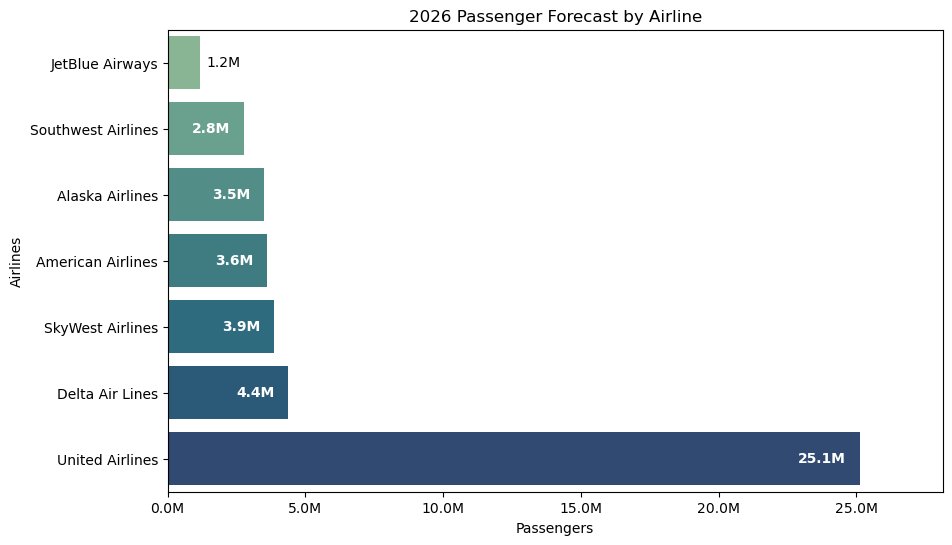

In [16]:
# Airline Forecast 2026

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

plt.figure(figsize=(10,6))

# Sort airlines by forecasted passengers (ascending for horizontal bars)
plot_df = results_df_active.sort_values('2026 Forecast')

sns.barplot(
    data=plot_df,
    y='Airline',
    x='2026 Forecast',
    hue='Airline',
    palette='crest',
    legend=False
)

plt.title('2026 Passenger Forecast by Airline')

ax = plt.gca()

# Format x-axis in millions (e.g., 12.5M)
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

plt.xlabel('Passengers')
plt.ylabel('Airlines')

# Extend x-axis slightly so labels are not clipped
ax.set_xlim(0, plot_df['2026 Forecast'].max() * 1.12)

# Add value labels to bars
for p in ax.patches:
    w = p.get_width()
    h = p.get_height()

    if h < 0.3 or w <= 0:
        continue

    y = p.get_y() + h/2
    label = f'{w/1e6:.1f}M'

    # For very small bars — place label outside
    if w < plot_df['2026 Forecast'].max() * 0.08:
        ax.text(
            w + plot_df['2026 Forecast'].max() * 0.01,
            y,
            label,
            va='center',
            ha='left',
            color='black'
        )

    # For larger bars — place label inside (right-aligned)
    else:
        ax.text(
            w - plot_df['2026 Forecast'].max() * 0.02,
            y,
            label,
            va='center',
            ha='right',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

plt.show()

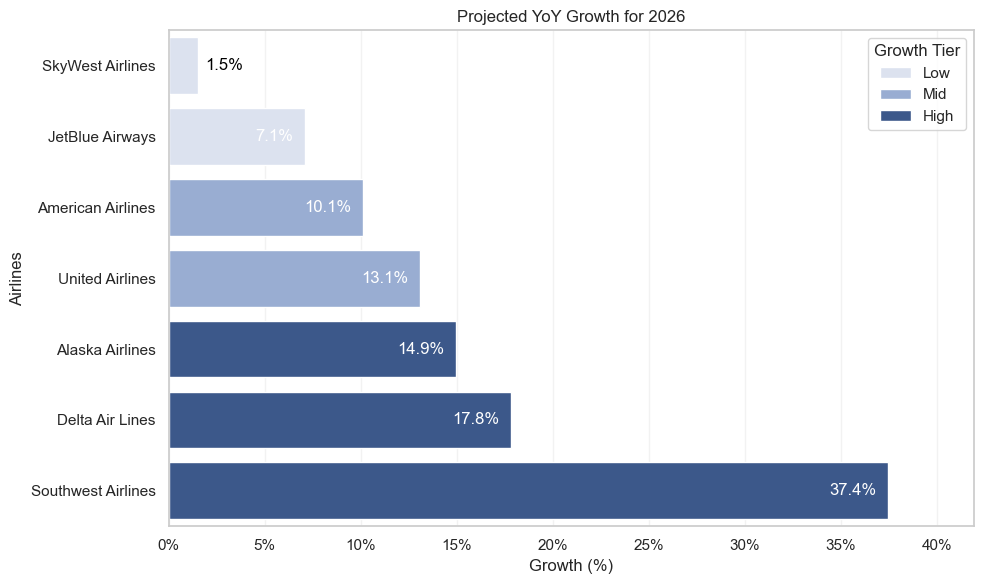

In [17]:
# YoY Growth ranking

from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

# Sort airlines by YoY growth (ascending for horizontal bars)
plot_df = results_df_active.sort_values('YoY Growth %').copy()

# --- Split airlines into Low / Mid / High growth tiers ---
plot_df['Growth Tier'] = pd.qcut(
    plot_df['YoY Growth %'],
    q=3,
    labels=['Low', 'Mid', 'High']
)

# Calm corporate-style color palette
palette = {
    'Low':  '#D9E1F2',
    'Mid':  '#8FAADC',
    'High': '#2F5597'
}

ax = sns.barplot(
    data=plot_df,
    y='Airline',
    x='YoY Growth %',
    hue='Growth Tier',
    palette=palette,
    dodge=False
)

ax.set_title('Projected YoY Growth for 2026')
ax.set_xlabel('Growth (%)')
ax.set_ylabel('Airlines')

# Format x-axis as percentages
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.0f}%'))

# Power BI–style grid
ax.grid(axis='y', visible=False)
ax.grid(axis='x', alpha=0.25)

# Extend x-axis slightly so labels are not clipped
ax.set_xlim(0, plot_df['YoY Growth %'].max() * 1.12)

# Remove old labels in case the cell was re-run
for t in list(ax.texts):
    t.remove()

# Add labels only to actual bars
for p in ax.patches:
    w = p.get_width()
    h = p.get_height()

    # Filter out legend or decorative rectangles (very small height)
    if h < 0.3 or w <= 0:
        continue

    y = p.get_y() + h/2

    # Small bars — label outside
    if w < 3:
        ax.text(
            w + 0.4,
            y,
            f'{w:.1f}%',
            va='center',
            ha='left',
            color='black'
        )
    # Larger bars — label inside (right-aligned)
    else:
        ax.text(
            w - 0.6,
            y,
            f'{w:.1f}%',
            va='center',
            ha='right',
            color='white'
        )

plt.legend(title='Growth Tier')
plt.tight_layout()
plt.show()

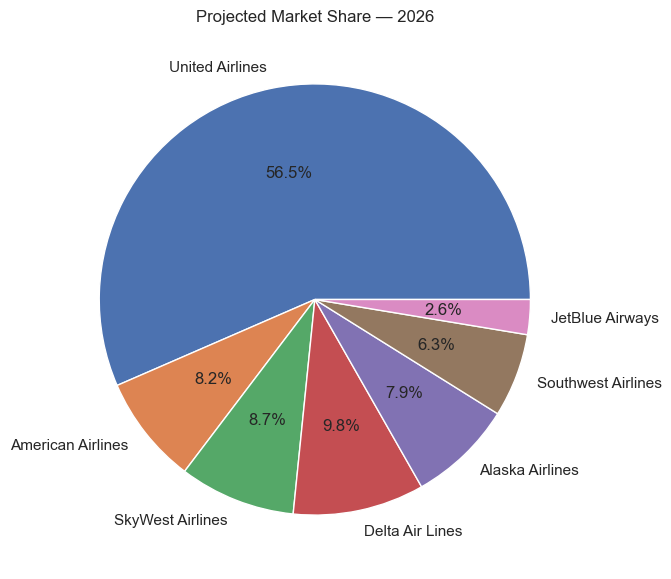

In [18]:
# Market share 2026

# Projected market share for 2026 (pie chart)

# Create a copy to avoid modifying the original results
share_2026 = results_df_active.copy()

# Compute each airline's share of total forecasted passengers
share_2026['Market Share %'] = (
    share_2026['2026 Forecast'] /
    share_2026['2026 Forecast'].sum() * 100
)

plt.figure(figsize=(7,7))

# Plot pie chart of market share distribution
plt.pie(
    share_2026['Market Share %'],
    labels=share_2026['Airline'],
    autopct='%1.1f%%'  # Display percentages on slices
)

plt.title('Projected Market Share — 2026')

plt.show()